# TAPNext
## INF8225 – Projet : TAPNext: Tracking Any Point as Next Token Prediction

Ce notebook couvre les expériences suivantes :
1. Influence de la **taille de l'image en entrée** sur la précision spatiale
2. Influence de la **méthode d'interpolation** sur la précision spatiale
3. Tests avec l'**augmentation du nombre de query points**
4. Analyse des différents modèles TAPNext
**Benchmark** : TAP-Vid DAVIS  
**Métriques** : Average Jaccard (AJ), Occlusion Accuracy (OA), δ_avg (coordinate accuracy)
5. Généralisation sur TAP-Vid Kinetics

---
## 0. Installation et imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Installation des dépendances
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python matplotlib seaborn pandas numpy tqdm
!pip install -q mediapy

# Cloner le repo TAPNext
!git clone https://github.com/google-deepmind/tapnet.git 2>/dev/null || echo 'Repo déjà cloné'
%cd /content/tapnet
!pip install -q -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.6 MB/s eta 0:00:00
/content/tapnet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.5 MB/s eta 0:00:00
  Building editable for tapnet (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviou

In [3]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import torch
import warnings
import tarfile
import gc
import pickle
import time

warnings.filterwarnings('ignore')

# Palette de couleurs cohérente pour les figures
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
sns.set_theme(style='whitegrid', palette='muted')

print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
GPU disponible  : True
GPU             : NVIDIA L4


---
## 1. Configuration générale et chargement du modèle

In [4]:
DRIVE_DIR       = '/content/drive/MyDrive/INF8225'
CHECKPOINT_PATH = f'{DRIVE_DIR}/bootstapnext_ckpt.npz'
DAVIS_DATA_PATH = f'{DRIVE_DIR}/tapvid_davis/tapvid_davis.pkl'
DEFAULT_RESOLUTION = (256, 256)
N_VIDEOS_ABLATION  = None
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(CHECKPOINT_PATH)
print(os.path.exists(CHECKPOINT_PATH))

/content/drive/MyDrive/INF8225/bootstapnext_ckpt.npz
True


In [5]:
# Chargement des datasets David et du modèle bootstapnext
DRIVE_DIR = '/content/drive/MyDrive/INF8225'
os.makedirs(DRIVE_DIR, exist_ok=True)

!wget -q -nc -P {DRIVE_DIR} https://storage.googleapis.com/dm-tapnet/tapnext/bootstapnext_ckpt.npz
!wget -q -nc -P {DRIVE_DIR} https://storage.googleapis.com/dm-tapnet/tapnext/tapnext_ckpt.npz
!wget -q -nc --no-check-certificate -P {DRIVE_DIR} https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip
!unzip -q -n {DRIVE_DIR}/tapvid_davis.zip -d {DRIVE_DIR}/

print('Fichiers dans Drive :')
for f in os.listdir(DRIVE_DIR):
    print(f'  {f}')

# Résolution de référence (celle utilisée dans l'article)
DEFAULT_RESOLUTION = (256, 256)

# Nombre de vidéos DAVIS à utiliser pour les ablations rapides
N_VIDEOS_ABLATION = None

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device utilisé : {DEVICE}')

Fichiers dans Drive :
  TAPNext_Alexis_Experiments.ipynb
  tapvid_davis.zip
  tapvid_kinetics.zip
  tapnext_ckpt.npz
  bootstapnext_ckpt.npz
  tapvid_davis
  exp_A_resolution.csv
  fig_A_resolution.png
  tensorflow_datasets
  exp_B_interpolation.csv
  fig_B_interpolation.png
  tapvid_kinetics
  exp_C_npoints.csv
  fig_C_npoints.png
  exp_D_coord_head.csv
  fig_D_comparaison_modeles.png
  resolution_aj_latency.pdf
  resolution_aj_latency.png
  interpolation.pdf
  interpolation.png
  npoints.png
  npoints.pdf
  coord_head.pdf
  coord_head.png
  fig_benchmark_kinetics_davis.png
  benchmark_kinetics_davis.csv
Device utilisé : cuda


In [6]:
from tapnet import evaluation_datasets
from tapnet.tapnext.tapnext_torch import TAPNext
from tapnet.tapnext.tapnext_torch_utils import restore_model_from_jax_checkpoint, tracker_certainty
import torch.nn.functional as F

model = TAPNext(
    image_size=(256, 256), width=768, patch_size=(8,8),
    num_heads=12, lru_width=768, depth=12
).to(DEVICE)
model.eval()
restore_model_from_jax_checkpoint(model, CHECKPOINT_PATH)

print('Modèle chargé')
print(f'Paramètres : {sum(p.numel() for p in model.parameters())/1e6:.0f}M')

Modèle chargé
Paramètres : 194M


In [7]:
# Fonctions utilitaires
def compute_tapvid_metrics(pred_coords, pred_visibility, gt_coords, gt_visibility,
                            query_mode='first'):
    """
    Calcule les 3 métriques TAP-Vid :
      - OA  : Occlusion Accuracy
      - delta_avg : Average coordinate accuracy (seuils 1,2,4,8,16 px)
      - AJ  : Average Jaccard (combinaison OA + delta)

    Paramètres
    pred_coords     : np.ndarray [T, Q, 2]  – coordonnées prédites (x, y)
    pred_visibility : np.ndarray [T, Q]     – visibilité prédite (0/1)
    gt_coords       : np.ndarray [T, Q, 2]  – vérité terrain
    gt_visibility   : np.ndarray [T, Q]     – visibilité vérité terrain
    """
    T, Q = gt_visibility.shape

    # Occlusion Accuracy
    pred_vis_binary = (pred_visibility > 0.5).astype(float)
    oa = np.mean(pred_vis_binary == gt_visibility)

    # Coordinate Accuracy (δ_avg)
    thresholds = [1, 2, 4, 8, 16]
    # Seulement sur les frames où le point est visible dans la GT
    visible_mask = gt_visibility.astype(bool)  # [T, Q]
    dists = np.linalg.norm(pred_coords - gt_coords, axis=-1)  # [T, Q]

    delta_avg = 0.0
    for thresh in thresholds:
        within_thresh = (dists[visible_mask] < thresh).mean()
        delta_avg += within_thresh
    delta_avg /= len(thresholds)

    # Average Jaccard
    # AJ = moyenne des Jaccard pour chaque seuil
    aj = 0.0
    for thresh in thresholds:
        tp = np.sum((dists < thresh) & visible_mask & pred_vis_binary.astype(bool))
        fp = np.sum((dists >= thresh) & visible_mask & pred_vis_binary.astype(bool))
        fn = np.sum(~pred_vis_binary.astype(bool) & visible_mask)
        jaccard = tp / (tp + fp + fn + 1e-8)
        aj += jaccard
    aj /= len(thresholds)

    return {'OA': oa * 100, 'delta_avg': delta_avg * 100, 'AJ': aj * 100}


def aggregate_metrics(results_list):
    """Moyenne des métriques sur plusieurs vidéos."""
    keys = results_list[0].keys()
    return {k: np.mean([r[k] for r in results_list]) for k in keys}


print('Fonctions de métriques définies.')

Fonctions de métriques définies.


In [8]:
# Chargement des données
import pickle

def load_davis_dataset(path, n_videos=None):
    """
    Charge le dataset TAP-Vid DAVIS.
    Retourne une liste de dict avec clés :
      'video'      : np.ndarray [T, H, W, 3] uint8
      'points'     : np.ndarray [Q, 2]  – coordonnées query (frame 0)
      'gt_tracks'  : np.ndarray [T, Q, 2]
      'gt_occluded': np.ndarray [T, Q]  bool  (True = occulté)
    """
    with open(path, 'rb') as f:
        data = pickle.load(f)
    videos = list(data.values())
    if n_videos is not None:
        videos = videos[:n_videos]
    print(f'Dataset chargé : {len(videos)} vidéos')
    return videos


def preprocess_video(video, target_resolution):
    """
    Redimensionne une vidéo vers `target_resolution` (H, W).
    Retourne la vidéo redimensionnée et le facteur d'échelle (scale_x, scale_y).
    """
    T, orig_H, orig_W, C = video.shape
    target_H, target_W = target_resolution
    resized = np.stack([
        cv2.resize(video[t], (target_W, target_H), interpolation=cv2.INTER_LINEAR)
        for t in range(T)
    ])
    scale_x = target_W / orig_W
    scale_y = target_H / orig_H
    return resized, (scale_x, scale_y)


# Chargement (commenté si le fichier n'est pas encore disponible)
davis_videos = load_davis_dataset(DAVIS_DATA_PATH, n_videos=N_VIDEOS_ABLATION)
print('Fonction de chargement définie. Décommenter la ligne ci-dessus quand le dataset est disponible.')

Dataset chargé : 30 vidéos
Fonction de chargement définie. Décommenter la ligne ci-dessus quand le dataset est disponible.


---
## 2. Expérience A – Influence de la taille de l'image en entrée

**Objectif** : Évaluer comment la résolution d'entrée affecte la précision spatiale du modèle.

**Protocole** :
- Résolutions testées : 128×128, 192×192, 256×256 (référence), 320×320, 384×384
- Même modèle (TAPNext-B) pour toutes les résolutions
- Évaluation sur TAP-Vid DAVIS (query-first)
- Les coordonnées prédites sont ramenées à la résolution originale avant le calcul des métriques


In [ ]:
import torch.nn.functional as F

def load_model_for_resolution(res, checkpoint_path):
    """Charge TAPNext et interpole les pos embeddings pour la résolution donnée."""
    # Charger d'abord à 256x256 (résolution du checkpoint)
    m = TAPNext(
        image_size=(256, 256), width=768, patch_size=(8,8),
        num_heads=12, lru_width=768, depth=12
    ).to(DEVICE)
    m.eval()
    restore_model_from_jax_checkpoint(m, checkpoint_path)

    # Interpoler les pos embeddings si résolution différente
    if res != (256, 256):
        h_new = res[0] // 8  # patch_size=8
        w_new = res[1] // 8
        h_old = 256 // 8  # = 32
        w_old = 256 // 8  # = 32

        # pos_emb shape : [1, h*w, C] → reshape → interpoler → reshape
        emb = m.image_pos_emb.data  # [1, 1024, 768]
        C = emb.shape[-1]
        emb = emb.reshape(1, h_old, w_old, C).permute(0, 3, 1, 2)  # [1, C, h, w]
        emb = F.interpolate(emb, size=(h_new, w_new), mode='bilinear', align_corners=False)
        emb = emb.permute(0, 2, 3, 1).reshape(1, h_new * w_new, C)
        m.image_pos_emb = torch.nn.Parameter(emb)

    return m

In [ ]:
def run_resolution_experiment(resolutions):
    results = []
    for res in resolutions:
        res_label = f'{res[0]}×{res[1]}'
        print(f'\nRésolution : {res_label}')

        m = load_model_for_resolution(res, CHECKPOINT_PATH)
        m.eval()

        ds = evaluation_datasets.create_davis_dataset(
            davis_points_path=DAVIS_DATA_PATH,
            query_mode='first',
            full_resolution=False,
            resolution=res,
        )

        all_aj, all_oa, all_delta, all_latency, all_latency_per_frame = [], [], [], [], []
        for j, batch in enumerate(tqdm(ds, desc=res_label)):
            b = batch['davis']
            b['visible'] = ~b['occluded'][..., None]

            video    = torch.tensor(b['video']).float().to(DEVICE)
            q_points = torch.tensor(b['query_points']).float().to(DEVICE)

            torch.cuda.synchronize()
            t0 = time.perf_counter()

            with torch.no_grad():
                pred_tracks, track_logits, vis_logits, state = m(
                    video=video[:, :1], query_points=q_points
                )
                all_t = [pred_tracks.cpu()]
                all_v = [vis_logits.cpu()]
                all_l = [track_logits.cpu()]
                for t in range(1, video.shape[1]):
                    ct, cl, cv, state = m(video=video[:, t:t+1], state=state)
                    all_t.append(ct.cpu())
                    all_v.append(cv.cpu())
                    all_l.append(cl.cpu())

            torch.cuda.synchronize()
            n_frames = video.shape[1]
            all_latency.append((time.perf_counter() - t0) * 1000)           # ms total
            all_latency_per_frame.append((time.perf_counter() - t0) * 1000 / n_frames)  # ms/frame

            tracks   = torch.cat(all_t, dim=1).transpose(1, 2)
            vis      = torch.cat(all_v, dim=1).transpose(1, 2)
            logits   = torch.cat(all_l, dim=1).transpose(1, 2)
            occluded = ~(vis > 0).squeeze(-1)

            metrics = evaluation_datasets.compute_tapvid_metrics(
                query_points=b['query_points'],
                gt_occluded=b['occluded'],
                gt_tracks=b['target_points'],
                pred_occluded=occluded.numpy(),
                pred_tracks=tracks.numpy()[..., ::-1],
                query_mode='first',
            )
            all_aj.append(float(metrics['average_jaccard'].mean()))
            all_oa.append(float(metrics['occlusion_accuracy'].mean()))
            all_delta.append(float(metrics['average_pts_within_thresh'].mean()))

            if N_VIDEOS_ABLATION is not None and j + 1 >= N_VIDEOS_ABLATION:
                break

        row = {
            'Resolution': res_label, 'H': res[0], 'N_pixels': res[0]*res[1],
            'AJ':         np.mean(all_aj)      * 100,
            'delta_avg':  np.mean(all_delta)   * 100,
            'OA':         np.mean(all_oa)      * 100,
            'Latency_ms_total':     np.mean(all_latency),
            'Latency_ms_per_frame': np.mean(all_latency_per_frame),
        }
        results.append(row)
        print(f'  AJ={row["AJ"]:.1f}  δ_avg={row["delta_avg"]:.1f}  OA={row["OA"]:.1f}  Latence_total={row["Latency_ms_total"]:.1f}ms  Latence/frame={row["Latency_ms_per_frame"]:.1f}ms')

        del m
        torch.cuda.empty_cache()

    df = pd.DataFrame(results)
    df.to_csv(f'{DRIVE_DIR}/exp_A_resolution.csv', index=False)
    return df

RESOLUTIONS_TO_TEST = [(128,128),(192,192),(256,256),(320,320),(384,384)]

df_resolution = run_resolution_experiment(RESOLUTIONS_TO_TEST)
print(df_resolution[['Resolution','AJ','delta_avg','OA','Latency_ms_total','Latency_ms_per_frame']].to_string(index=False))


Résolution : 128×128


128×128: 30it [01:24,  2.81s/it]


  AJ=9.8  δ_avg=24.6  OA=43.3  Latence_total=2128.4ms  Latence/frame=32.0ms

Résolution : 192×192


192×192: 30it [01:50,  3.69s/it]


  AJ=14.1  δ_avg=24.2  OA=62.3  Latence_total=2975.3ms  Latence/frame=44.7ms

Résolution : 256×256


...

  AJ=66.6  δ_avg=79.5  OA=92.2  Latence_total=5199.7ms  Latence/frame=78.0ms

Résolution : 320×320


320×320: 30it [04:16,  8.56s/it]


  AJ=9.2  δ_avg=16.7  OA=60.5  Latence_total=7665.7ms  Latence/frame=115.1ms

Résolution : 384×384


384×384: 30it [06:06, 12.21s/it]

  AJ=5.8  δ_avg=10.7  OA=55.0  Latence_total=11209.7ms  Latence/frame=168.3ms
Resolution        AJ  delta_avg        OA  Latency_ms_total  Latency_ms_per_frame
   128×128  9.758577  24.608904 43.342538       2128.430047             31.956165
   192×192 14.084322  24.179301 62.342138       2975.299882             44.658103
   256×256 66.551985  79.487033 92.166558       5199.730723             77.990723
   320×320  9.247369  16.653163 60.473146       7665.689914            115.074496
   384×384  5.772263  10.664755 54.979141      11209.654869            168.265175


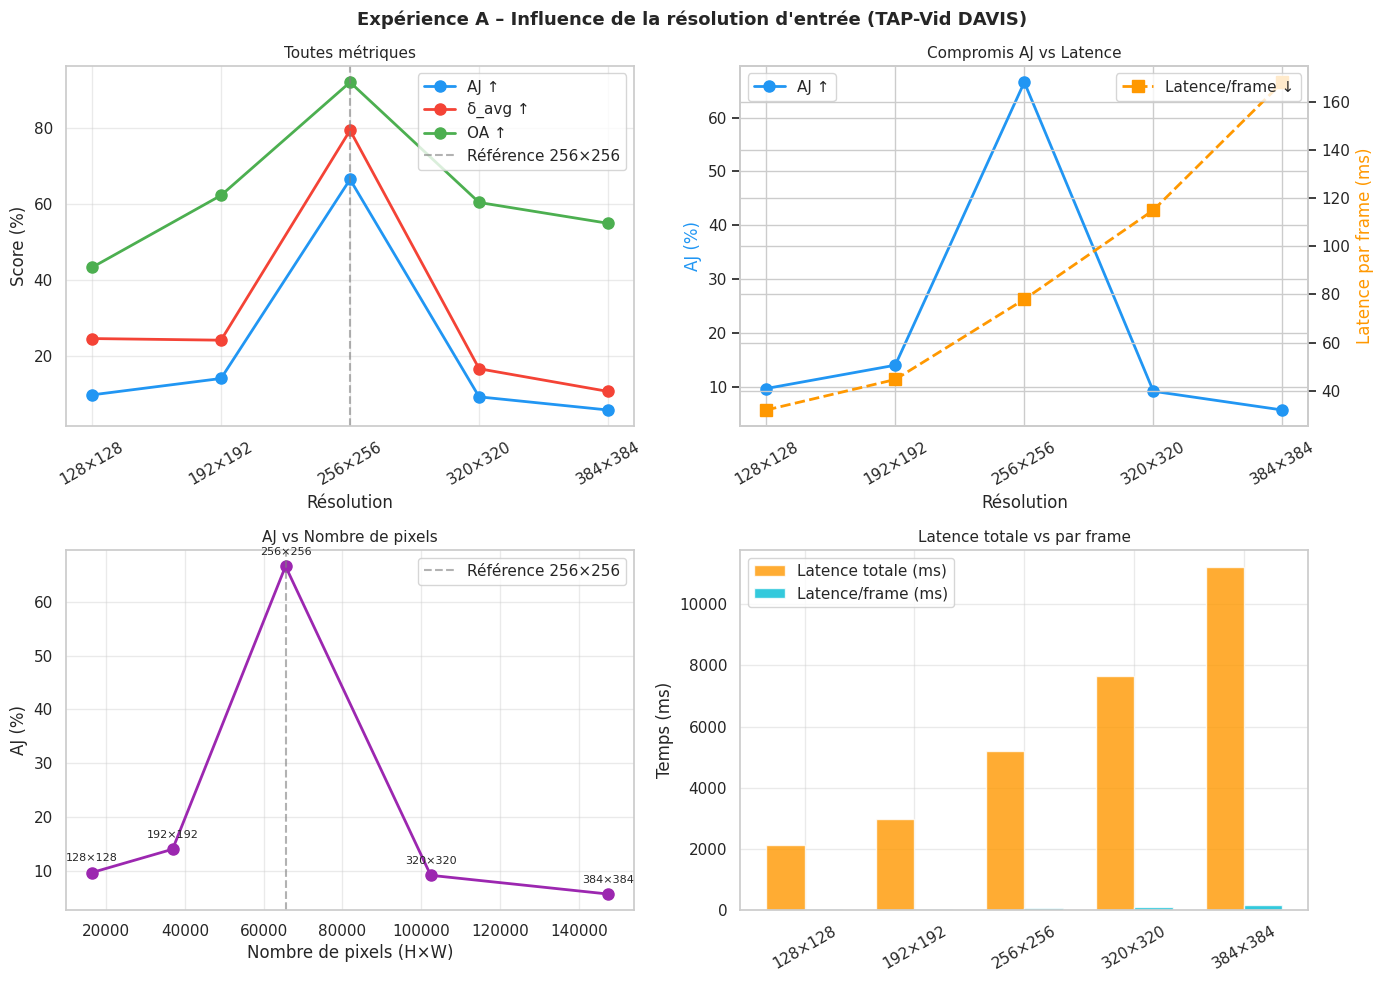

Figure sauvegardée → /content/drive/MyDrive/INF8225/fig_A_resolution.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expérience A – Influence de la résolution d\'entrée (TAP-Vid DAVIS)',
             fontsize=13, fontweight='bold')

#  AJ, delta_avg, OA sur le même graphe
ax = axes[0, 0]
for metric, label, color in [('AJ', 'AJ ↑', COLORS[0]),
                               ('delta_avg', 'δ_avg ↑', COLORS[1]),
                               ('OA', 'OA ↑', COLORS[2])]:
    ax.plot(df_resolution['Resolution'], df_resolution[metric],
            'o-', color=color, linewidth=2, markersize=8, label=label)
ax.axvline(x=2, linestyle='--', color='gray', alpha=0.6, label='Référence 256×256')
ax.set_title('Toutes métriques', fontsize=11)
ax.set_xlabel('Résolution'); ax.set_ylabel('Score (%)')
ax.tick_params(axis='x', rotation=30); ax.legend(); ax.grid(alpha=0.4)

#  AJ vs Latence/frame (compromis vitesse/précision)
ax = axes[0, 1]
ax2 = ax.twinx()
ax.plot(df_resolution['Resolution'], df_resolution['AJ'],
        'o-', color=COLORS[0], linewidth=2, markersize=8, label='AJ ↑')
ax2.plot(df_resolution['Resolution'], df_resolution['Latency_ms_per_frame'],
         's--', color=COLORS[3], linewidth=2, markersize=8, label='Latence/frame ↓')
ax.set_title('Compromis AJ vs Latence', fontsize=11)
ax.set_xlabel('Résolution')
ax.set_ylabel('AJ (%)', color=COLORS[0])
ax2.set_ylabel('Latence par frame (ms)', color=COLORS[3])
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

#  AJ vs N_pixels (courbe de scaling)
ax = axes[1, 0]
ax.plot(df_resolution['N_pixels'], df_resolution['AJ'],
        'o-', color=COLORS[4], linewidth=2, markersize=8)
for _, row in df_resolution.iterrows():
    ax.annotate(row['Resolution'], (row['N_pixels'], row['AJ']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.axvline(x=256*256, linestyle='--', color='gray', alpha=0.6, label='Référence 256×256')
ax.set_title('AJ vs Nombre de pixels', fontsize=11)
ax.set_xlabel('Nombre de pixels (H×W)'); ax.set_ylabel('AJ (%)')
ax.legend(); ax.grid(alpha=0.4)

#  Latence totale vs latence/frame
ax = axes[1, 1]
x = np.arange(len(df_resolution))
width = 0.35
ax.bar(x - width/2, df_resolution['Latency_ms_total'],    width, label='Latence totale (ms)',   color=COLORS[3], alpha=0.8)
ax.bar(x + width/2, df_resolution['Latency_ms_per_frame'], width, label='Latence/frame (ms)',    color=COLORS[5], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(df_resolution['Resolution'], rotation=30)
ax.set_title('Latence totale vs par frame', fontsize=11)
ax.set_ylabel('Temps (ms)'); ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
fig_path = f'{DRIVE_DIR}/fig_A_resolution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée → {fig_path}')

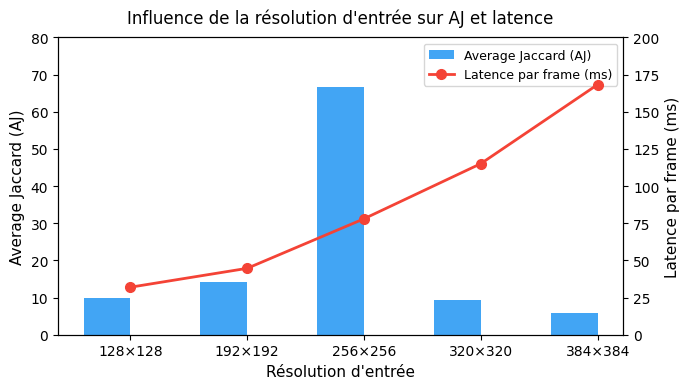

In [ ]:
df = pd.read_csv(f'{DRIVE_DIR}/exp_A_resolution.csv')

fig, ax1 = plt.subplots(figsize=(7, 4))

color_aj = '#2196F3'
color_lat = '#F44336'

x = np.arange(len(df))
width = 0.4

bars = ax1.bar(x - width/2, df['AJ'], width, color=color_aj, alpha=0.85, label='Average Jaccard (AJ)')
ax1.set_ylabel('Average Jaccard (AJ)', fontsize=11)
ax1.tick_params(axis='y')
ax1.set_ylim(0, 80)
ax1.set_xticks(x)
ax1.set_xticklabels(df['Resolution'], fontsize=10)
ax1.set_xlabel("Résolution d'entrée", fontsize=11)

ax2 = ax1.twinx()
ax2.plot(x, df['Latency_ms_per_frame'], color=color_lat, marker='o', linewidth=2,
         markersize=7, label='Latence par frame (ms)')
ax2.set_ylabel('Latence par frame (ms)', fontsize=11)
ax2.tick_params(axis='y')
ax2.set_ylim(0, 200)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)


plt.title("Influence de la résolution d'entrée sur AJ et latence", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/resolution_aj_latency.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{DRIVE_DIR}/resolution_aj_latency.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Expérience B – Influence de la méthode d'interpolation

**Objectif** : Comparer différentes méthodes d'interpolation lors du redimensionnement des images en entrée.

**Protocole** :
- Résolution fixée à 256×256
- Interpolations testées : NEAREST, BILINEAR (référence), BICUBIC, AREA, LANCZOS
- Même modèle et dataset que l'expérience A

**Hypothèse** : Les interpolations haute qualité (BICUBIC, LANCZOS) pourraient améliorer la précision pour les objets petits ou texturés.

In [ ]:
from tapnet.tapvid.evaluation_datasets import sample_queries_first

IMAGE_INTERP_METHODS = {
    'NEAREST':  cv2.INTER_NEAREST,
    'BILINEAR': cv2.INTER_LINEAR,
    'BICUBIC':  cv2.INTER_CUBIC,
    'AREA':     cv2.INTER_AREA,
    'LANCZOS':  cv2.INTER_LANCZOS4,
}

def run_interpolation_experiment(interp_methods, resolution=(256, 256)):
    with open(DAVIS_DATA_PATH, 'rb') as f:
        davis_pkl = pickle.load(f)

    results = []
    for name, interp_flag in interp_methods.items():
        print(f'\nInterpolation : {name}')

        all_aj, all_oa, all_delta, all_latency = [], [], [], []
        for j, (video_name, vid) in enumerate(tqdm(davis_pkl.items(), desc=name)):

            # Reproduire exactement create_davis_dataset mais avec notre interpolation
            frames = vid['video']  # [T, H, W, 3] uint8
            T, orig_H, orig_W, _ = frames.shape

            # Resize avec notre méthode
            frames_resized = np.stack([
                cv2.resize(frames[t], (resolution[1], resolution[0]),
                           interpolation=interp_flag)
                for t in range(T)
            ])  # [T, 256, 256, 3] uint8

            # Normalisation identique au dataset
            frames_norm = frames_resized.astype(np.float32) / 255.0 * 2.0 - 1.0  # [-1,1]

            # Coordonnées → pixels 256×256 (identique au dataset)
            target_points = vid['points'] * np.array([resolution[1], resolution[0]])
            target_occ    = vid['occluded']

            # sample_queries_first identique au dataset
            converted = sample_queries_first(target_occ, target_points, frames_norm)

            del frames, frames_resized
            gc.collect()

            video_t  = torch.tensor(converted['video']).float().to(DEVICE)
            q_points = torch.tensor(converted['query_points']).float().to(DEVICE)

            torch.cuda.synchronize()
            t0 = time.perf_counter()

            with torch.no_grad():
                pred_tracks, _, vis_logits, state = model(
                    video=video_t[:, :1], query_points=q_points
                )
                all_t = [pred_tracks.cpu()]
                all_v = [vis_logits.cpu()]
                for t in range(1, video_t.shape[1]):
                    ct, _, cv, state = model(video=video_t[:, t:t+1], state=state)
                    all_t.append(ct.cpu())
                    all_v.append(cv.cpu())
                    torch.cuda.empty_cache()

            torch.cuda.synchronize()
            all_latency.append((time.perf_counter() - t0) * 1000 / video_t.shape[1])

            del video_t, q_points
            torch.cuda.empty_cache()

            tracks   = torch.cat(all_t, dim=1).transpose(1, 2)
            vis      = torch.cat(all_v, dim=1).transpose(1, 2)
            occluded = ~(vis > 0).squeeze(-1)
            del all_t, all_v

            metrics = evaluation_datasets.compute_tapvid_metrics(
                query_points=converted['query_points'],
                gt_occluded=converted['occluded'],
                gt_tracks=converted['target_points'],
                pred_occluded=occluded.numpy(),
                pred_tracks=tracks.numpy()[..., ::-1],
                query_mode='first',
            )
            del tracks, occluded
            gc.collect()

            all_aj.append(float(metrics['average_jaccard'].mean()))
            all_oa.append(float(metrics['occlusion_accuracy'].mean()))
            all_delta.append(float(metrics['average_pts_within_thresh'].mean()))

            if N_VIDEOS_ABLATION is not None and j + 1 >= N_VIDEOS_ABLATION:
                break

        row = {
            'Interpolation':    name,
            'AJ':               np.mean(all_aj)      * 100,
            'delta_avg':        np.mean(all_delta)   * 100,
            'OA':               np.mean(all_oa)      * 100,
            'Latency_ms_frame': np.mean(all_latency),
        }
        results.append(row)
        print(f'  AJ={row["AJ"]:.1f}  δ_avg={row["delta_avg"]:.1f}  OA={row["OA"]:.1f}  Latence/frame={row["Latency_ms_frame"]:.1f}ms')

        gc.collect()
        torch.cuda.empty_cache()

    df = pd.DataFrame(results)
    df.to_csv(f'{DRIVE_DIR}/exp_B_interpolation.csv', index=False)
    print(f'\nSauvegardé → {DRIVE_DIR}/exp_B_interpolation.csv')
    return df

df_interp = run_interpolation_experiment(IMAGE_INTERP_METHODS)
print(df_interp.to_string(index=False))


Interpolation : NEAREST


NEAREST: 100%|██████████| 30/30 [03:00<00:00,  6.01s/it]


  AJ=63.7  δ_avg=77.3  OA=91.4  Latence/frame=79.6ms

Interpolation : BILINEAR


BILINEAR: 100%|██████████| 30/30 [03:00<00:00,  6.02s/it]


  AJ=66.3  δ_avg=79.2  OA=92.3  Latence/frame=79.6ms

Interpolation : BICUBIC


...

  AJ=66.1  δ_avg=79.1  OA=92.2  Latence/frame=79.6ms

Interpolation : AREA


AREA: 100%|██████████| 30/30 [03:05<00:00,  6.18s/it]


  AJ=66.4  δ_avg=79.4  OA=92.3  Latence/frame=79.8ms

Interpolation : LANCZOS


LANCZOS: 100%|██████████| 30/30 [03:05<00:00,  6.20s/it]


  AJ=66.1  δ_avg=79.0  OA=92.2  Latence/frame=79.6ms

Sauvegardé → /content/drive/MyDrive/INF8225/exp_B_interpolation.csv
Interpolation        AJ  delta_avg        OA  Latency_ms_frame
      NEAREST 63.727911  77.271833 91.402630         79.615616
     BILINEAR 66.290933  79.229707 92.276470         79.570615
      BICUBIC 66.129255  79.050336 92.230592         79.632252
         AREA 66.437326  79.429179 92.316419         79.768072
      LANCZOS 66.099941  79.017088 92.216925         79.620736


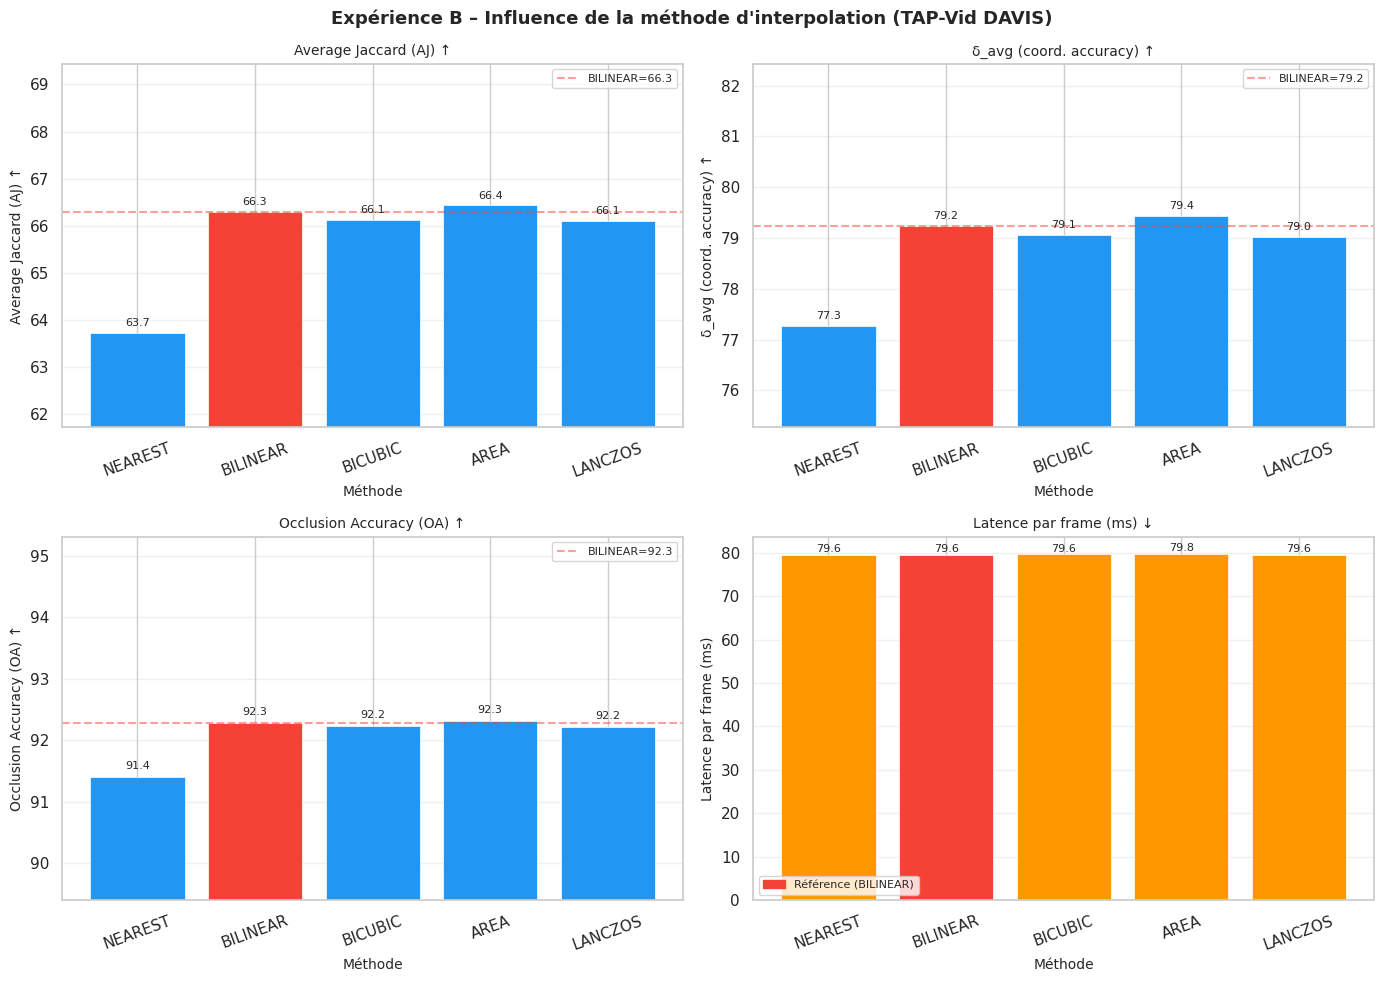

Figure sauvegardée → /content/drive/MyDrive/INF8225/fig_B_interpolation.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expérience B – Influence de la méthode d\'interpolation (TAP-Vid DAVIS)',
             fontsize=13, fontweight='bold')

metrics_list = [('AJ', 'Average Jaccard (AJ) ↑'),
                ('delta_avg', 'δ_avg (coord. accuracy) ↑'),
                ('OA', 'Occlusion Accuracy (OA) ↑')]

#  AJ, delta_avg, OA en barres
for ax, (metric, label) in zip(axes.flat[:3], metrics_list):
    bar_colors = [COLORS[1] if m == 'BILINEAR' else COLORS[0] for m in df_interp['Interpolation']]
    bars = ax.bar(df_interp['Interpolation'], df_interp[metric],
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    # Référence BILINEAR
    ref_val = df_interp.loc[df_interp['Interpolation'] == 'BILINEAR', metric].values[0]
    ax.axhline(ref_val, linestyle='--', color=COLORS[1], alpha=0.5, label=f'BILINEAR={ref_val:.1f}')
    # Annotations
    for bar, val in zip(bars, df_interp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_xlabel('Méthode', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    y_min = df_interp[metric].min() - 2
    y_max = df_interp[metric].max() + 3
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', alpha=0.3)

#  Latence par méthode
ax = axes[1, 1]
bar_colors = [COLORS[1] if m == 'BILINEAR' else COLORS[3] for m in df_interp['Interpolation']]
bars = ax.bar(df_interp['Interpolation'], df_interp['Latency_ms_frame'],
              color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, df_interp['Latency_ms_frame']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Méthode', fontsize=10)
ax.set_ylabel('Latence par frame (ms)', fontsize=10)
ax.set_title('Latence par frame (ms) ↓', fontsize=10)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
ref_patch = mpatches.Patch(color=COLORS[1], label='Référence (BILINEAR)')
ax.legend(handles=[ref_patch], fontsize=8)

plt.tight_layout()
fig_path = f'{DRIVE_DIR}/fig_B_interpolation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée → {fig_path}')

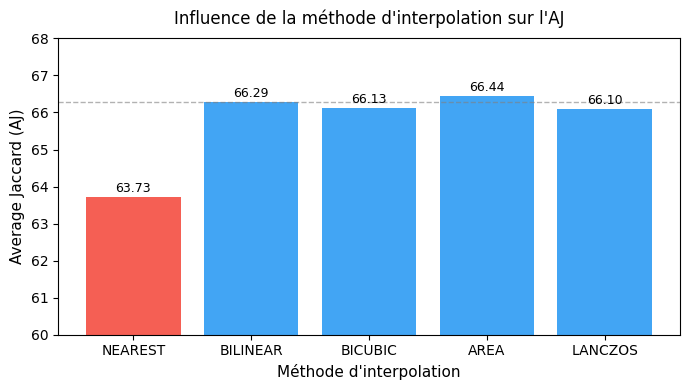

In [ ]:
df = pd.read_csv(f'{DRIVE_DIR}/exp_B_interpolation.csv')

fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#F44336' if m == 'NEAREST' else '#2196F3' for m in df['Interpolation']]
bars = ax.bar(df['Interpolation'], df['AJ'], color=colors, alpha=0.85)

ax.set_ylabel('Average Jaccard (AJ)', fontsize=11)
ax.set_xlabel('Méthode d\'interpolation', fontsize=11)
ax.set_ylim(60, 68)
ax.axhline(y=df[df['Interpolation'] == 'BILINEAR']['AJ'].values[0],
           color='gray', linestyle='--', linewidth=1, alpha=0.6)

for bar, val in zip(bars, df['AJ']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.title("Influence de la méthode d'interpolation sur l'AJ", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/interpolation.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{DRIVE_DIR}/interpolation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Expérience C – Augmentation du nombre de query points

**Objectif** : Analyser comment le nombre de points à suivre simultanément (Q) affecte les performances et la vitesse.

**Protocole** :
- Nombre de query points testés : 16, 64, 128, 256 (référence), 512, 1024
- Les query points sont échantillonnés uniformément sur la première frame
- Mesure des métriques ET de la latence

**Hypothèse** : Le traitement conjoint des points par TAPNext (via self-attention) pourrait bénéficier d'un plus grand nombre de points (contexte riche), mais au coût d'une mémoire et latence plus élevées.

In [ ]:
N_QUERY_POINTS_LIST = [5, 15, 25, 64, 128, 256, 512, 1024]

def run_npoints_experiment(n_points_list, resolution=(256, 256)):
    results = []
    for n_pts in n_points_list:
        print(f'\nQ = {n_pts} query points')

        ds = evaluation_datasets.create_davis_dataset(
            davis_points_path=DAVIS_DATA_PATH,
            query_mode='first',
            full_resolution=False,
            resolution=resolution,
        )

        all_aj, all_oa, all_delta = [], [], []
        all_latency_total, all_latency_frame = [], []

        for j, batch in enumerate(tqdm(ds, desc=f'Q={n_pts}')):
            b = batch['davis']
            b['visible'] = ~b['occluded'][..., None]

            Q_gt = b['query_points'].shape[1]

            if n_pts <= Q_gt:
                # Sous-échantillonnage prendre les premiers n_pts points GT
                q_pts = b['query_points'][:, :n_pts]
                t_pts = b['target_points'][:, :n_pts]
                occ   = b['occluded'][:, :n_pts]

            else:
                # Sur-échantillonnage ajouter des points aléatoires
                rng   = np.random.RandomState(42)
                extra = n_pts - Q_gt

                # Générer des points aléatoires en coordonnées 256×256
                # format query_points : (frame_idx, y, x)
                xs = rng.uniform(5, 251, extra).astype(np.float32)  # éviter les bords
                ys = rng.uniform(5, 251, extra).astype(np.float32)
                extra_q = np.zeros((1, extra, 3), dtype=np.float32)
                extra_q[0, :, 0] = 0   # frame 0
                extra_q[0, :, 1] = ys  # y
                extra_q[0, :, 2] = xs  # x

                # Combiner GT + points aléatoires pour le modèle
                q_pts_model = np.concatenate(
                    [b['query_points'], extra_q], axis=1
                )  # [1, n_pts, 3]

                # Garder seulement les GT pour les métriques
                q_pts = b['query_points']   # [1, Q_gt, 3]
                t_pts = b['target_points']  # [1, Q_gt, T, 2]
                occ   = b['occluded']       # [1, Q_gt, T]

            video_t  = torch.tensor(b['video']).float().to(DEVICE)

            # Utiliser q_pts_model si sur-échantillonnage, sinon q_pts
            q_input = q_pts_model if n_pts > Q_gt else q_pts
            q_points = torch.tensor(q_input).float().to(DEVICE)

            torch.cuda.synchronize()
            t0 = time.perf_counter()

            with torch.no_grad():
                pred_tracks, _, vis_logits, state = model(
                    video=video_t[:, :1], query_points=q_points
                )
                all_t = [pred_tracks.cpu()]
                all_v = [vis_logits.cpu()]
                for t in range(1, video_t.shape[1]):
                    ct, _, cv, state = model(video=video_t[:, t:t+1], state=state)
                    all_t.append(ct.cpu())
                    all_v.append(cv.cpu())
                    torch.cuda.empty_cache()

            torch.cuda.synchronize()
            n_frames = video_t.shape[1]
            elapsed_ms = (time.perf_counter() - t0) * 1000
            all_latency_total.append(elapsed_ms)
            all_latency_frame.append(elapsed_ms / n_frames)

            del video_t, q_points
            torch.cuda.empty_cache()

            tracks = torch.cat(all_t, dim=1).transpose(1, 2)  # [1, n_pts, T, 2]
            vis    = torch.cat(all_v, dim=1).transpose(1, 2)
            pred_occ = ~(vis > 0).squeeze(-1)
            del all_t, all_v

            # Métriques uniquement sur les Q_gt points GT
            metrics = evaluation_datasets.compute_tapvid_metrics(
                query_points=q_pts,
                gt_occluded=occ,
                gt_tracks=t_pts,
                pred_occluded=pred_occ.numpy()[:, :Q_gt],
                pred_tracks=tracks.numpy()[:, :Q_gt][..., ::-1],
                query_mode='first',
            )
            del tracks, pred_occ
            gc.collect()

            all_aj.append(float(metrics['average_jaccard'].mean()))
            all_oa.append(float(metrics['occlusion_accuracy'].mean()))
            all_delta.append(float(metrics['average_pts_within_thresh'].mean()))

            if N_VIDEOS_ABLATION is not None and j + 1 >= N_VIDEOS_ABLATION:
                break

        row = {
            'Q':                n_pts,
            'Q_gt_max':         Q_gt,
            'AJ':               np.mean(all_aj)          * 100,
            'delta_avg':        np.mean(all_delta)        * 100,
            'OA':               np.mean(all_oa)           * 100,
            'Latency_ms_total': np.mean(all_latency_total),
            'Latency_ms_frame': np.mean(all_latency_frame),
        }
        results.append(row)
        print(f'  AJ={row["AJ"]:.1f}  δ_avg={row["delta_avg"]:.1f}  OA={row["OA"]:.1f}  '
              f'Latence_total={row["Latency_ms_total"]:.1f}ms  Latence/frame={row["Latency_ms_frame"]:.1f}ms')

        gc.collect()
        torch.cuda.empty_cache()

    df = pd.DataFrame(results)
    df.to_csv(f'{DRIVE_DIR}/exp_C_npoints.csv', index=False)
    print(f'\nSauvegardé → {DRIVE_DIR}/exp_C_npoints.csv')
    return df

df_npoints = run_npoints_experiment(N_QUERY_POINTS_LIST)
print(df_npoints[['Q','Q_gt_max','AJ','delta_avg','OA','Latency_ms_total','Latency_ms_frame']].to_string(index=False))


Q = 5 query points


Q=5: 30it [03:06,  6.21s/it]


  AJ=65.1  δ_avg=77.0  OA=91.7  Latence_total=5120.8ms  Latence/frame=76.7ms

Q = 15 query points


Q=15: 30it [03:10,  6.34s/it]


  AJ=65.9  δ_avg=78.5  OA=91.5  Latence_total=5246.3ms  Latence/frame=78.8ms

Q = 25 query points


...

  AJ=65.5  δ_avg=78.8  OA=91.4  Latence_total=6178.1ms  Latence/frame=92.7ms

Q = 512 query points


Q=512: 30it [04:00,  8.02s/it]


  AJ=65.7  δ_avg=78.8  OA=91.9  Latence_total=6925.2ms  Latence/frame=104.0ms

Q = 1024 query points


Q=1024: 30it [05:17, 10.58s/it]


  AJ=65.7  δ_avg=78.6  OA=91.7  Latence_total=9489.5ms  Latence/frame=142.4ms

Sauvegardé → /content/drive/MyDrive/INF8225/exp_C_npoints.csv
   Q  Q_gt_max        AJ  delta_avg        OA  Latency_ms_total  Latency_ms_frame
   5        25 65.094281  77.006169 91.717695       5120.796020         76.733333
  15        25 65.868603  78.526583 91.450085       5246.277998         78.770551
  25        25 66.511946  79.483570 92.139849       5263.384951         78.987045
  64        25 66.249505  79.342448 91.805034       5335.615209         80.114737
 128        25 65.808138  79.017957 91.843594       5347.775874         80.340950
 256        25 65.469451  78.794848 91.387523       6178.096953         92.709211
 512        25 65.695687  78.786945 91.889426       6925.196222        103.973627
1024        25 65.724063  78.586264 91.724866       9489.547661        142.442093


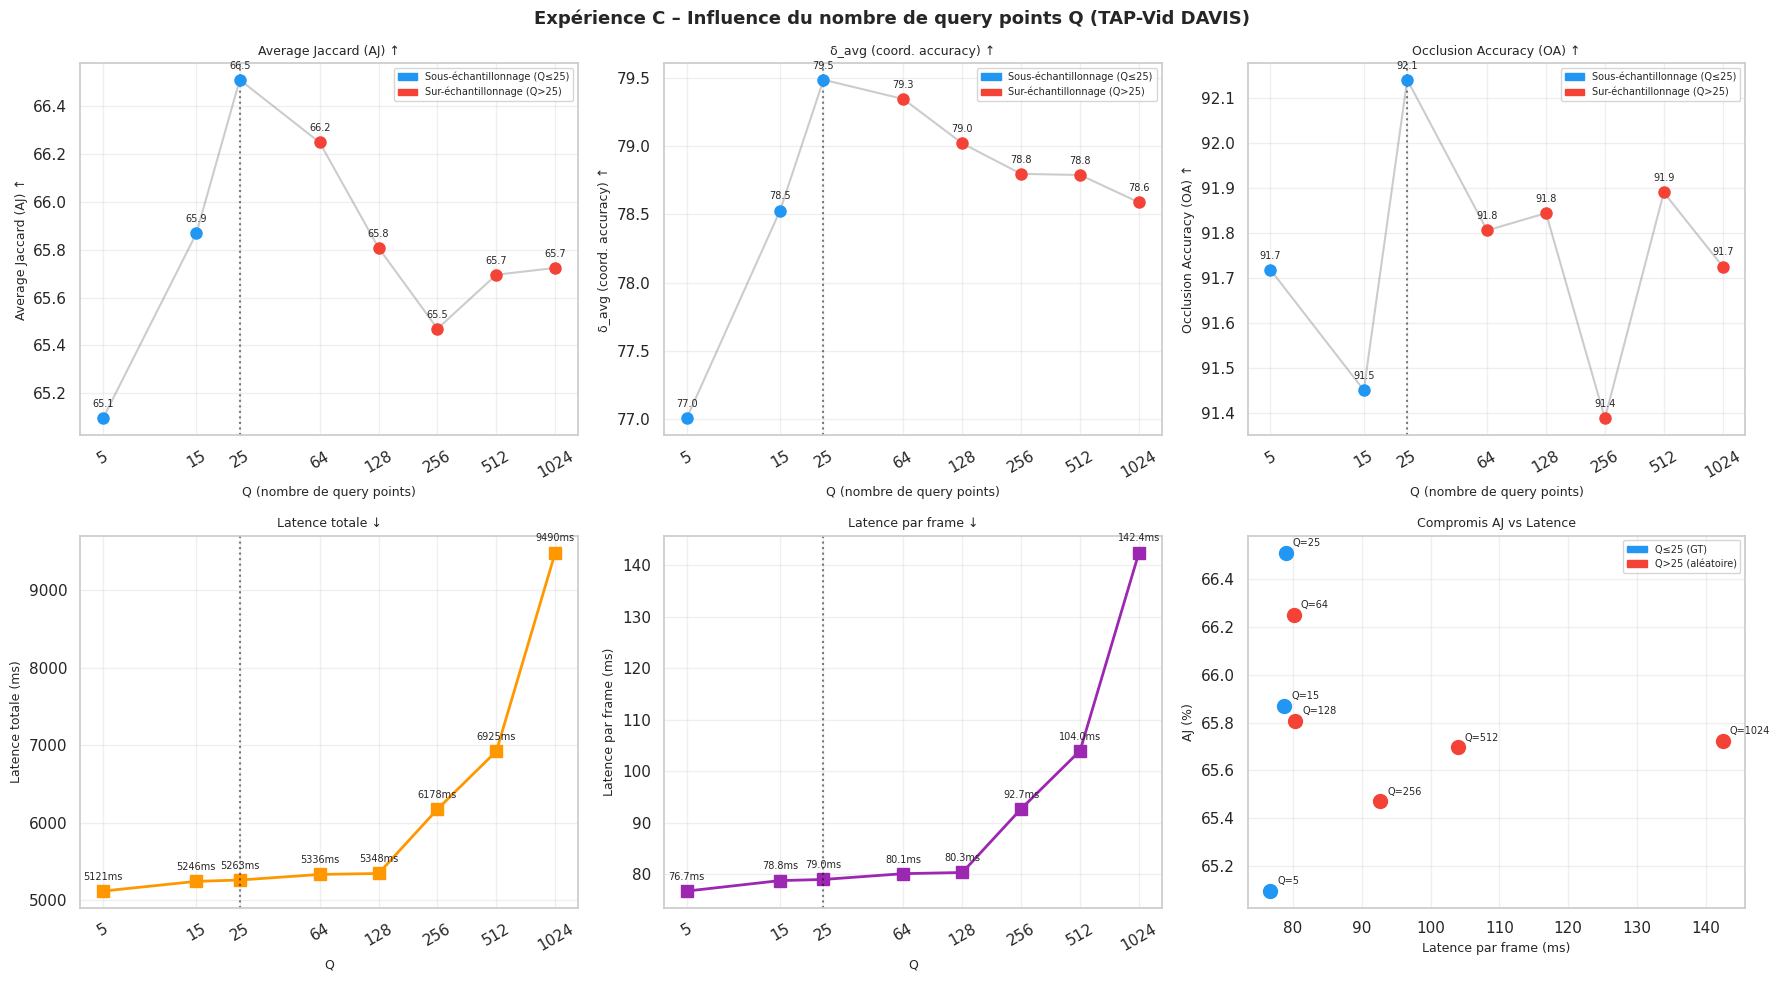

Figure sauvegardée → /content/drive/MyDrive/INF8225/fig_C_npoints.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Expérience C – Influence du nombre de query points Q (TAP-Vid DAVIS)',
             fontsize=13, fontweight='bold')

metrics_list = [('AJ', 'Average Jaccard (AJ) ↑'),
                ('delta_avg', 'δ_avg (coord. accuracy) ↑'),
                ('OA', 'Occlusion Accuracy (OA) ↑')]

# Ligne de séparation sous-échantillonnage / sur-échantillonnage
# DAVIS a max 25 points → Q>25 = sur-échantillonnage
Q_max_gt = 25

# AJ, delta_avg, OA vs Q
for ax, (metric, label) in zip(axes[0], metrics_list):
    # Colorier différemment sous vs sur échantillonnage
    for _, row in df_npoints.iterrows():
        color = COLORS[0] if row['Q'] <= Q_max_gt else COLORS[1]
        ax.plot(row['Q'], row[metric], 'o', color=color, markersize=8, zorder=5)
    ax.plot(df_npoints['Q'], df_npoints[metric], '-', color='gray', alpha=0.4, linewidth=1.5)

    # Ligne verticale séparant sous/sur échantillonnage
    ax.axvline(x=Q_max_gt, linestyle=':', color='black', alpha=0.5, label='Max GT (25)')

    ax.set_xlabel('Q (nombre de query points)', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.set_xscale('log')
    ax.set_xticks(df_npoints['Q'])
    ax.set_xticklabels(df_npoints['Q'], rotation=30)

    # Annotations des valeurs
    for _, row in df_npoints.iterrows():
        ax.annotate(f'{row[metric]:.1f}', (row['Q'], row[metric]),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=7)

    # Légende couleurs
    patch_sub = mpatches.Patch(color=COLORS[0], label='Sous-échantillonnage (Q≤25)')
    patch_sur = mpatches.Patch(color=COLORS[1], label='Sur-échantillonnage (Q>25)')
    ax.legend(handles=[patch_sub, patch_sur], fontsize=7)
    ax.grid(alpha=0.3)

# Latence totale vs Q
ax = axes[1, 0]
ax.plot(df_npoints['Q'], df_npoints['Latency_ms_total'], 's-',
        color=COLORS[3], linewidth=2, markersize=8)
ax.axvline(x=Q_max_gt, linestyle=':', color='black', alpha=0.5)
for _, row in df_npoints.iterrows():
    ax.annotate(f'{row["Latency_ms_total"]:.0f}ms', (row['Q'], row['Latency_ms_total']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)
ax.set_xlabel('Q', fontsize=9); ax.set_ylabel('Latence totale (ms)', fontsize=9)
ax.set_title('Latence totale ↓', fontsize=9)
ax.set_xscale('log'); ax.set_xticks(df_npoints['Q'])
ax.set_xticklabels(df_npoints['Q'], rotation=30); ax.grid(alpha=0.3)

# Latence par frame vs Q
ax = axes[1, 1]
ax.plot(df_npoints['Q'], df_npoints['Latency_ms_frame'], 's-',
        color=COLORS[4], linewidth=2, markersize=8)
ax.axvline(x=Q_max_gt, linestyle=':', color='black', alpha=0.5)
for _, row in df_npoints.iterrows():
    ax.annotate(f'{row["Latency_ms_frame"]:.1f}ms', (row['Q'], row['Latency_ms_frame']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)
ax.set_xlabel('Q', fontsize=9); ax.set_ylabel('Latence par frame (ms)', fontsize=9)
ax.set_title('Latence par frame ↓', fontsize=9)
ax.set_xscale('log'); ax.set_xticks(df_npoints['Q'])
ax.set_xticklabels(df_npoints['Q'], rotation=30); ax.grid(alpha=0.3)

# AJ vs Latence/frame (compromis)
ax = axes[1, 2]
for _, row in df_npoints.iterrows():
    color = COLORS[0] if row['Q'] <= Q_max_gt else COLORS[1]
    ax.scatter(row['Latency_ms_frame'], row['AJ'], s=100, color=color, zorder=5)
    ax.annotate(f'Q={int(row["Q"])}', (row['Latency_ms_frame'], row['AJ']),
                textcoords='offset points', xytext=(5, 5), fontsize=7)
ax.set_xlabel('Latence par frame (ms)', fontsize=9)
ax.set_ylabel('AJ (%)', fontsize=9)
ax.set_title('Compromis AJ vs Latence', fontsize=9)
patch_sub = mpatches.Patch(color=COLORS[0], label='Q≤25 (GT)')
patch_sur = mpatches.Patch(color=COLORS[1], label='Q>25 (aléatoire)')
ax.legend(handles=[patch_sub, patch_sur], fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = f'{DRIVE_DIR}/fig_C_npoints.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée → {fig_path}')

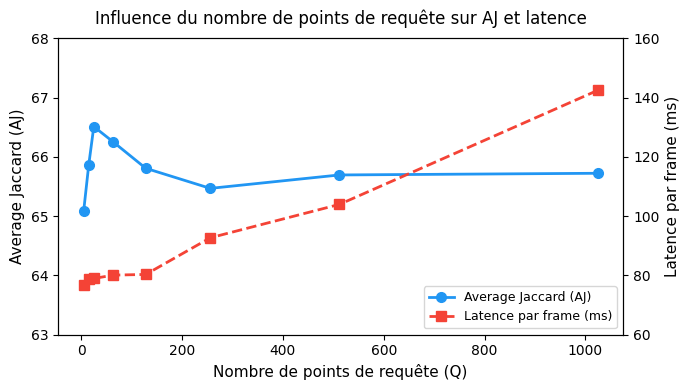

In [ ]:
df = pd.read_csv(f'{DRIVE_DIR}/exp_C_npoints.csv')

fig, ax1 = plt.subplots(figsize=(7, 4))

color_aj = '#2196F3'
color_lat = '#F44336'

ax1.plot(df['Q'], df['AJ'], color=color_aj, marker='o', linewidth=2,
         markersize=7, label='Average Jaccard (AJ)')
ax1.set_ylabel('Average Jaccard (AJ)', fontsize=11)
ax1.tick_params(axis='y')
ax1.set_ylim(63, 68)
ax1.set_xlabel('Nombre de points de requête (Q)', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(df['Q'], df['Latency_ms_frame'], color=color_lat, marker='s', linewidth=2,
         markersize=7, linestyle='--', label='Latence par frame (ms)')
ax2.set_ylabel('Latence par frame (ms)', fontsize=11)
ax2.tick_params(axis='y')
ax2.set_ylim(60, 160)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.title('Influence du nombre de points de requête sur AJ et latence',
          fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/npoints.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Expérience D – Modèle synthétique vs Modèle affiné sur données réelles

**Objectif** : Quantifier l’apport de l’affinage auto-supervisé et mesurer la réduction de l’écart de généralisation entre données synthétiques et vidéos naturelles.

**Méthodologie** :
L’impossibilité de modifier l’architecture (tête de classification vs régression) pour des raisons de ressources GPU et de disponibilité des poids nous a conduits à recentrer l’étude sur la procédure d’entraînement. Nous comparons deux versions de l'architecture TAPNext-B :

TAPNext : Modèle de base, entraîné uniquement sur les données synthétiques Kubric.

BootsTAPNext : Modèle affiné sur des vidéos réelles via le schéma enseignant-étudiant de BootsTAP.

In [ ]:
def eval_model_davis(m, label):
    """Évalue un modèle sur toutes les vidéos DAVIS."""
    ds = evaluation_datasets.create_davis_dataset(
        davis_points_path=DAVIS_DATA_PATH,
        query_mode='first',
        full_resolution=False,
        resolution=(256, 256),
    )
    all_aj, all_oa, all_delta, all_latency = [], [], [], []

    for j, batch in enumerate(tqdm(ds, desc=label)):
        b = batch['davis']
        b['visible'] = ~b['occluded'][..., None]

        video_t  = torch.tensor(b['video']).float().to(DEVICE)
        q_points = torch.tensor(b['query_points']).float().to(DEVICE)

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        with torch.no_grad():
            pred_tracks, _, vis_logits, state = m(
                video=video_t[:, :1], query_points=q_points
            )
            all_t = [pred_tracks.cpu()]
            all_v = [vis_logits.cpu()]
            for t in range(1, video_t.shape[1]):
                ct, _, cv, state = m(video=video_t[:, t:t+1], state=state)
                all_t.append(ct.cpu())
                all_v.append(cv.cpu())
                torch.cuda.empty_cache()

        torch.cuda.synchronize()
        all_latency.append((time.perf_counter() - t0) * 1000 / video_t.shape[1])

        del video_t, q_points
        torch.cuda.empty_cache()

        tracks   = torch.cat(all_t, dim=1).transpose(1, 2)
        vis      = torch.cat(all_v, dim=1).transpose(1, 2)
        occluded = ~(vis > 0).squeeze(-1)
        del all_t, all_v

        metrics = evaluation_datasets.compute_tapvid_metrics(
            query_points=b['query_points'],
            gt_occluded=b['occluded'],
            gt_tracks=b['target_points'],
            pred_occluded=occluded.numpy(),
            pred_tracks=tracks.numpy()[..., ::-1],
            query_mode='first',
        )
        del tracks, occluded
        gc.collect()

        all_aj.append(float(metrics['average_jaccard'].mean()))
        all_oa.append(float(metrics['occlusion_accuracy'].mean()))
        all_delta.append(float(metrics['average_pts_within_thresh'].mean()))

        if N_VIDEOS_ABLATION is not None and j + 1 >= N_VIDEOS_ABLATION:
            break

    return {
        'AJ':               np.mean(all_aj)      * 100,
        'delta_avg':        np.mean(all_delta)   * 100,
        'OA':               np.mean(all_oa)      * 100,
        'Latency_ms_frame': np.mean(all_latency),
    }


# TAPNext (synthétique uniquement)
print('Chargement TAPNext (synthétique)...')
model_synth = TAPNext(
    image_size=(256,256), width=768, patch_size=(8,8),
    num_heads=12, lru_width=768, depth=12
).to(DEVICE)
model_synth.eval()
restore_model_from_jax_checkpoint(model_synth, f'{DRIVE_DIR}/tapnext_ckpt.npz')
print('Évaluation TAPNext synth...')
metrics_synth = eval_model_davis(model_synth, 'TAPNext-synth')
del model_synth
torch.cuda.empty_cache()
gc.collect()
print(f'TAPNext synth → AJ={metrics_synth["AJ"]:.1f}  δ_avg={metrics_synth["delta_avg"]:.1f}  OA={metrics_synth["OA"]:.1f}')

# BootsTAPNext (affiné sur données réelles)
print('\nÉvaluation BootsTAPNext...')
metrics_boots = eval_model_davis(model, 'BootsTAPNext')
print(f'BootsTAPNext   → AJ={metrics_boots["AJ"]:.1f}  δ_avg={metrics_boots["delta_avg"]:.1f}  OA={metrics_boots["OA"]:.1f}')

#  Tableau complet pour les visualisations
df_coord = pd.DataFrame([
    {'Configuration': 'TAPNext\n(synth only)',
     'Source': 'Nos exp.',
     **metrics_synth},
    {'Configuration': 'BootsTAPNext\n(synth + réel)',
     'Source': 'Nos exp.',
     **metrics_boots},
    {'Configuration': 'Classif+Reg\n(papier TAPNext-S)',
     'Source': 'Papier',
     'AJ': 55.0, 'delta_avg': None, 'OA': None, 'Latency_ms_frame': None},
    {'Configuration': 'Classification\nseule (papier)',
     'Source': 'Papier',
     'AJ': 52.7, 'delta_avg': None, 'OA': None, 'Latency_ms_frame': None},
    {'Configuration': 'Régression\nseule (papier)',
     'Source': 'Papier',
     'AJ': 44.7, 'delta_avg': None, 'OA': None, 'Latency_ms_frame': None},
    {'Configuration': 'Reg+Classif\n(papier)',
     'Source': 'Papier',
     'AJ': 48.1, 'delta_avg': None, 'OA': None, 'Latency_ms_frame': None},
])

df_coord.to_csv(f'{DRIVE_DIR}/exp_D_coord_head.csv', index=False)
print('\n=== Résultats Expérience D ===')
print(df_coord.to_string(index=False))

Chargement TAPNext (synthétique)...
Évaluation TAPNext synth...


TAPNext-synth: 30it [03:11,  6.37s/it]


TAPNext synth → AJ=62.8  δ_avg=77.0  OA=90.6

Évaluation BootsTAPNext...


BootsTAPNext: 30it [03:09,  6.33s/it]

BootsTAPNext   → AJ=66.6  δ_avg=79.5  OA=92.2

=== Résultats Expérience D ===
                  Configuration   Source        AJ  delta_avg        OA  Latency_ms_frame
          TAPNext\n(synth only) Nos exp. 62.832422  77.008992 90.553771         79.247147
   BootsTAPNext\n(synth + réel) Nos exp. 66.551985  79.487033 92.166558         79.033147
Classif+Reg\n(papier TAPNext-S)   Papier 55.000000        NaN       NaN               NaN
 Classification\nseule (papier)   Papier 52.700000        NaN       NaN               NaN
     Régression\nseule (papier)   Papier 44.700000        NaN       NaN               NaN
          Reg+Classif\n(papier)   Papier 48.100000        NaN       NaN               NaN


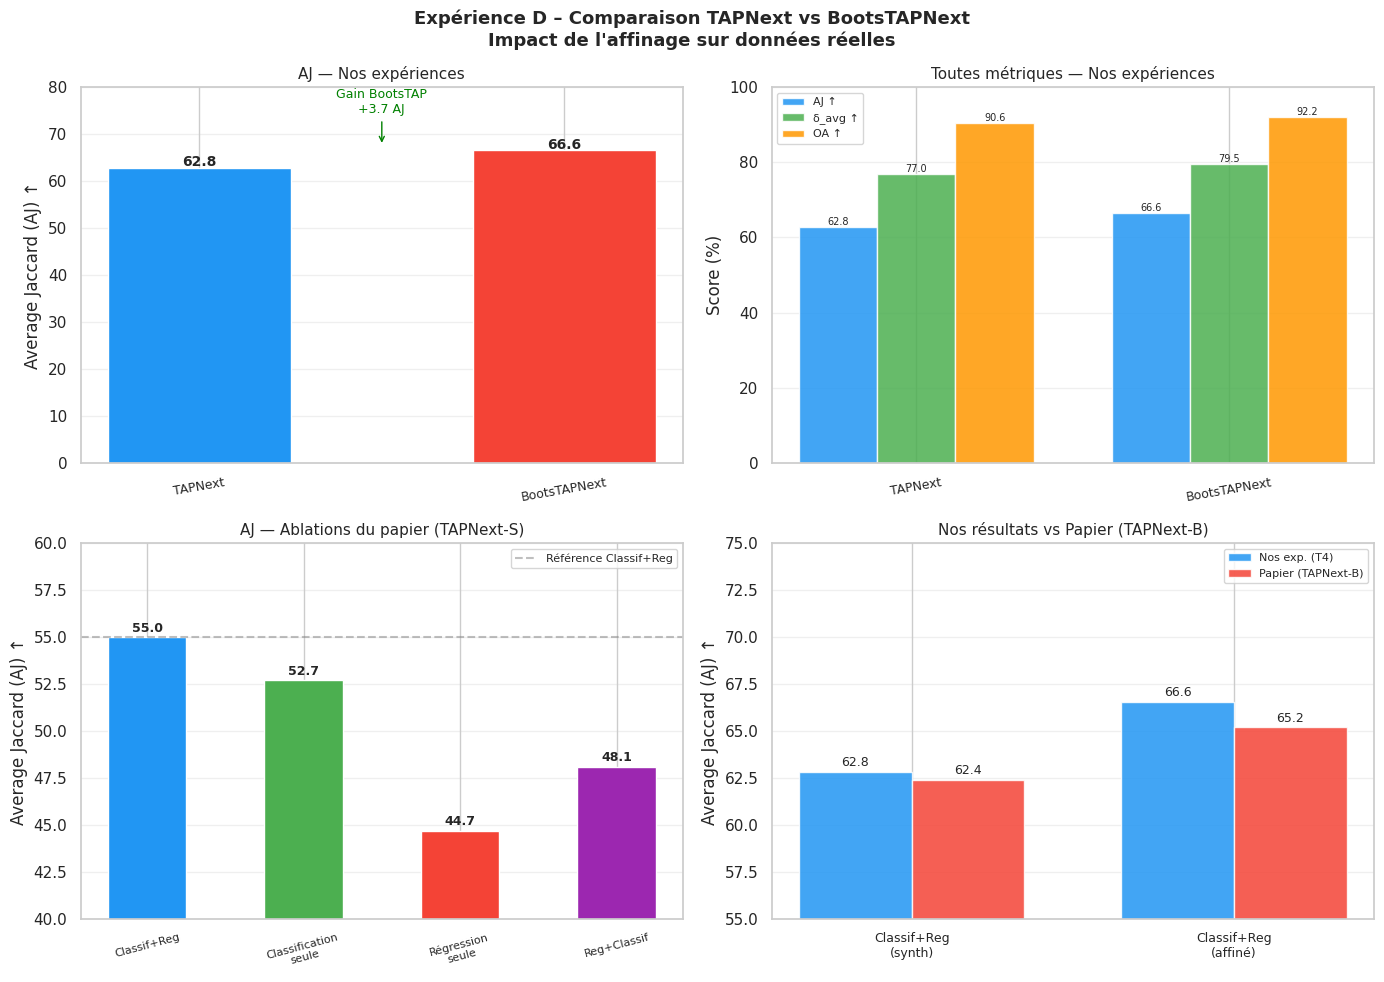

Figure sauvegardée → /content/drive/MyDrive/INF8225/fig_D_comparaison_modeles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expérience D – Comparaison TAPNext vs BootsTAPNext\nImpact de l\'affinage sur données réelles',
             fontsize=13, fontweight='bold')

# Données
models_nos    = df_coord[df_coord['Source'] == 'Nos exp.']
models_papier = df_coord[df_coord['Source'] == 'Papier']

configs_court = [c.split('(')[0].strip() for c in models_papier['Configuration']]

#  AJ 2 modèles vs papier
ax = axes[0, 0]
x = np.arange(len(models_nos))
bars = ax.bar(x, models_nos['AJ'], color=[COLORS[0], COLORS[1]],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, models_nos['AJ']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.split('(')[0].strip() for c in models_nos['Configuration']],
                   rotation=10, fontsize=9)
ax.set_ylabel('Average Jaccard (AJ) ↑')
ax.set_title('AJ — Nos expériences', fontsize=11)
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.3)

# Gain entre les deux
gain = models_nos['AJ'].values[1] - models_nos['AJ'].values[0]
ax.annotate(f'Gain BootsTAP\n+{gain:.1f} AJ',
            xy=(0.5, max(models_nos['AJ'].values) + 1),
            xycoords=('axes fraction', 'data'),
            ha='center', fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'),
            xytext=(0.5, max(models_nos['AJ'].values) + 8))

#  Toutes métriques
ax = axes[0, 1]
x = np.arange(2)
width = 0.25
labels_modeles = [c.split('(')[0].strip() for c in models_nos['Configuration']]
ax.bar(x - width, models_nos['AJ'],        width, label='AJ ↑',      color=COLORS[0], alpha=0.85)
ax.bar(x,         models_nos['delta_avg'], width, label='δ_avg ↑',   color=COLORS[2], alpha=0.85)
ax.bar(x + width, models_nos['OA'],        width, label='OA ↑',      color=COLORS[3], alpha=0.85)
for i, (_, row) in enumerate(models_nos.iterrows()):
    for j, (metric, offset) in enumerate([('AJ', -width), ('delta_avg', 0), ('OA', width)]):
        ax.text(i + offset, row[metric] + 0.5, f'{row[metric]:.1f}',
                ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels_modeles, rotation=10, fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Toutes métriques — Nos expériences', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

#  AJ ablations du papier
ax = axes[1, 0]
bars = ax.bar(np.arange(len(models_papier)),
              models_papier['AJ'],
              color=[COLORS[0], COLORS[2], COLORS[1], COLORS[4]],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, models_papier['AJ']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(np.arange(len(models_papier)))
ax.set_xticklabels(configs_court, rotation=15, fontsize=8)
ax.set_ylabel('Average Jaccard (AJ) ↑')
ax.set_title('AJ — Ablations du papier (TAPNext-S)', fontsize=11)
ax.set_ylim(40, 60)
ax.grid(axis='y', alpha=0.3)
ax.axhline(55.0, linestyle='--', color='gray', alpha=0.5, label='Référence Classif+Reg')
ax.legend(fontsize=8)

#  Comparaison nos résultats vs papier
ax = axes[1, 1]
categories = ['Classif+Reg\n(synth)', 'Classif+Reg\n(affiné)']
aj_nos     = models_nos['AJ'].values
# Référence papier TAPNext-B
aj_papier_b = [62.4, 65.2]  # TAPNext-B et BootsTAPNext-B du papier

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, aj_nos,      width, label='Nos exp. (T4)',        color=COLORS[0], alpha=0.85)
ax.bar(x + width/2, aj_papier_b, width, label='Papier (TAPNext-B)',   color=COLORS[1], alpha=0.85)
for i, (v1, v2) in enumerate(zip(aj_nos, aj_papier_b)):
    ax.text(i - width/2, v1 + 0.3, f'{v1:.1f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.3, f'{v2:.1f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylabel('Average Jaccard (AJ) ↑')
ax.set_title('Nos résultats vs Papier (TAPNext-B)', fontsize=11)
ax.set_ylim(55, 75)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = f'{DRIVE_DIR}/fig_D_comparaison_modeles.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée → {fig_path}')

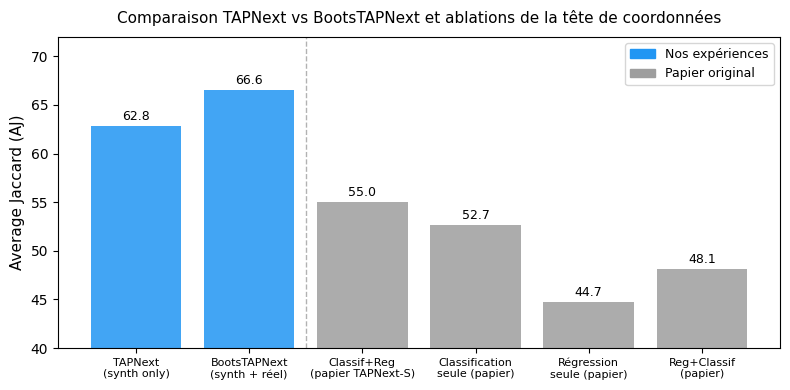

In [ ]:
df = pd.read_csv(f'{DRIVE_DIR}/exp_D_coord_head.csv')

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#2196F3' if s == 'Nos exp.' else '#9E9E9E' for s in df['Source']]
configs = [c.replace('\\n', '\n') for c in df['Configuration']]

bars = ax.bar(range(len(df)), df['AJ'], color=colors, alpha=0.85)

ax.set_xticks(range(len(df)))
ax.set_xticklabels(configs, fontsize=8, ha='center')
ax.set_ylabel('Average Jaccard (AJ)', fontsize=11)
ax.set_ylim(40, 72)

for bar, val in zip(bars, df['AJ']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(color='#2196F3', label='Nos expériences'),
                   Patch(color='#9E9E9E', label='Papier original')]
ax.legend(handles=legend_elements, fontsize=9)

ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

plt.title('Comparaison TAPNext vs BootsTAPNext et ablations de la tête de coordonnées',
          fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/coord_head.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{DRIVE_DIR}/coord_head.png', bbox_inches='tight', dpi=150)
plt.show()

## Benchmark sur le dataset Kinetics

In [ ]:
# Télécharger le script officiel de kinetics-dataset
!git clone -q https://github.com/cvdfoundation/kinetics-dataset.git /content/kinetics-dataset
!ls /content/kinetics-dataset

Total vidéos dans le CSV : 1147


In [ ]:
os.makedirs(f'{DRIVE_DIR}/tapvid_kinetics', exist_ok=True)

# Télécharger les annotations Kinetics (~annotations uniquement, sans les vidéos)
!wget -q -nc -P {DRIVE_DIR}/tapvid_kinetics https://storage.googleapis.com/dm-tapnet/tapvid_kinetics.zip
!unzip -q -n {DRIVE_DIR}/tapvid_kinetics/tapvid_kinetics.zip -d {DRIVE_DIR}/tapvid_kinetics/

print('Fichiers disponibles :')
!ls {DRIVE_DIR}/tapvid_kinetics/

Fichiers disponibles :
tapvid_kinetics  tapvid_kinetics.zip  videos


In [ ]:
df_kinetics = pd.read_csv(
    f'{DRIVE_DIR}/tapvid_kinetics/tapvid_kinetics/tapvid_kinetics.csv',
    header=None, usecols=[0,1,2],
    names=['youtube_id','start_sec','end_sec']
).drop_duplicates(subset='youtube_id')

ids_tapvid = set(df_kinetics['youtube_id'].tolist())

In [ ]:
tar_dir   = f'{DRIVE_DIR}/tapvid_kinetics/videos'
os.makedirs(tar_dir, exist_ok=True)

found_videos = []
tar_num = 1
max_vids = 100

while len(found_videos) < max_vids and tar_num < 300:
    tar_url  = f'https://s3.amazonaws.com/kinetics/700_2020/val/k700_val_{tar_num:03d}.tar.gz'
    tar_path = f'/tmp/k700_val_{tar_num:03d}.tar.gz'

    # Vérifier si le tar existe
    result = os.system(f'wget -q --spider {tar_url} 2>/dev/null')
    if result != 0:
        print(f'tar {tar_num:03d} non disponible — arrêt')
        break

    # Télécharger
    print(f'Téléchargement tar {tar_num:03d}... ({len(found_videos)}/{max_vids} vidéos trouvées)')
    os.system(f'wget -q -nc -P /tmp {tar_url}')

    # Extraire seulement les vidéos TAP-Vid
    try:
        with tarfile.open(tar_path, 'r:gz') as tar:
            all_files = tar.getnames()
            matches = [f for f in all_files if any(yt_id in f for yt_id in ids_tapvid)]
            print(f'  → {len(matches)} vidéos TAP-Vid trouvées')

            for match in matches:
                yt_id    = match.split('/')[-1].split('_')[0]
                dest     = f'{tar_dir}/{match.split("/")[-1]}'
                if not os.path.exists(dest):
                    member = tar.getmember(match)
                    member.name = os.path.basename(member.name)
                    tar.extract(member, path=tar_dir)
                found_videos.append(yt_id)
    except Exception as e:
        print(f'  Erreur : {e}')

    # Supprimer le tar pour économiser l'espace
    os.remove(tar_path)
    gc.collect()
    tar_num += 1

print(f'\nTotal vidéos TAP-Vid extraites : {len(found_videos)}')
print(f'Fichiers dans {tar_dir} : {len(os.listdir(tar_dir))}')

Téléchargement tar 001... (0/100 vidéos trouvées)
  → 2 vidéos TAP-Vid trouvées
Téléchargement tar 002... (2/100 vidéos trouvées)
  → 3 vidéos TAP-Vid trouvées
Téléchargement tar 003... (5/100 vidéos trouvées)
  → 1 vidéos TAP-Vid trouvées
Téléchargement tar 004... (6/100 vidéos trouvées)
  → 2 vidéos TAP-Vid trouvées
Téléchargement tar 005... (8/100 vidéos trouvées)
  → 0 vidéos TAP-Vid trouvées
Téléchargement tar 006... (8/100 vidéos trouvées)
  → 2 vidéos TAP-Vid trouvées
Téléchargement tar 007... (10/100 vidéos trouvées)
  → 3 vidéos TAP-Vid trouvées
Téléchargement tar 008... (13/100 vidéos trouvées)
  → 2 vidéos TAP-Vid trouvées
Téléchargement tar 009... (15/100 vidéos trouvées)
  → 3 vidéos TAP-Vid trouvées
Téléchargement tar 010... (18/100 vidéos trouvées)
  → 2 vidéos TAP-Vid trouvées
Téléchargement tar 011... (20/100 vidéos trouvées)
  → 1 vidéos TAP-Vid trouvées
Téléchargement tar 012... (21/100 vidéos trouvées)
  → 1 vidéos TAP-Vid trouvées
Téléchargement tar 013... (22/100 

In [21]:
# Benchmark Kinetics
import io
import time
from PIL import Image
from tapnet.tapvid.evaluation_datasets import sample_queries_first

KINETICS_VIDEO_DIR = f'{DRIVE_DIR}/tapvid_kinetics/videos'
KINETICS_CSV_PATH  = f'{DRIVE_DIR}/tapvid_kinetics/tapvid_kinetics/tapvid_kinetics.csv'


def extract_youtube_id(filename):
    name  = filename.replace('.mp4', '')
    parts = name.split('_')
    if len(parts) >= 3:
        return '_'.join(parts[:-2])
    return parts[0]


def load_kinetics_samples(video_dir, csv_path, n_videos=100):
    df         = pd.read_csv(csv_path, header=None)
    df_grouped = df.groupby(0)
    samples    = []
    video_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]
    print(f'Vidéos MP4 disponibles : {len(video_files)}')

    for video_file in tqdm(video_files[:n_videos], desc='Chargement Kinetics'):
        video_path = f'{video_dir}/{video_file}'
        yt_id      = extract_youtube_id(video_file)

        if yt_id not in df_grouped.groups:
            continue

        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

        if len(frames) == 0:
            continue

        # Rééchantillonner à 25fps si nécessaire (CSV annoté à 25fps)
        TARGET_FPS = 25
        if abs(fps - TARGET_FPS) > 0.5:
            total_duration = len(frames) / fps
            n_target       = int(round(total_duration * TARGET_FPS))
            indices        = np.linspace(0, len(frames) - 1, n_target).round().astype(int)
            frames         = [frames[i] for i in indices]

        T_video    = len(frames)
        frames_256 = np.stack([
            cv2.resize(f, (256, 256)).astype(np.float32) / 255.0 * 2.0 - 1.0
            for f in frames
        ])
        del frames
        gc.collect()

        rows     = df_grouped.get_group(yt_id).values
        T_csv    = (rows.shape[1] - 3) // 3
        n_points = len(rows)
        T        = min(T_video, T_csv)

        try:
            points   = np.zeros((n_points, T, 2), dtype=np.float32)
            occluded = np.zeros((n_points, T),    dtype=bool)

            for p, row in enumerate(rows):
                coords = row[3:].astype(float)
                for t in range(T):
                    idx = t * 3
                    points[p, t, 0] = coords[idx]      # x normalisé [0,1]
                    points[p, t, 1] = coords[idx + 1]  # y normalisé [0,1]
                    occluded[p, t]  = bool(coords[idx + 2])

            converted               = sample_queries_first(occluded, points, frames_256[:T])
            converted['video_name'] = yt_id
            samples.append(converted)

        except Exception as e:
            print(f'  Erreur parsing {yt_id} : {e}')
            continue

        del frames_256
        gc.collect()

    print(f'Echantillons chargés : {len(samples)}')
    return samples

def run_kinetics_benchmark(m, samples, label='BootsTAPNext'):
    from tapnet.tapvid import evaluation_datasets as ev

    all_aj, all_oa, all_delta, all_latency, all_latency_per_frame = [], [], [], [], []

    for sample in tqdm(samples, desc=f'Benchmark Kinetics [{label}]'):

        video    = torch.tensor(sample['video']).float().to(DEVICE)
        q_points = torch.tensor(sample['query_points']).float().to(DEVICE)

        # query_points en [0,1] → modèle attend pixels
        q_points_pixels = q_points.clone()
        q_points_pixels[..., 1:] = q_points[..., 1:] * 256

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        with torch.no_grad():
            pred_tracks, track_logits, vis_logits, state = m(
                video=video[:, :1], query_points=q_points_pixels
            )
            all_t = [pred_tracks.cpu()]
            all_v = [vis_logits.cpu()]
            all_l = [track_logits.cpu()]
            for t in range(1, video.shape[1]):
                ct, cl, cv, state = m(video=video[:, t:t + 1], state=state)
                all_t.append(ct.cpu())
                all_v.append(cv.cpu())
                all_l.append(cl.cpu())

        torch.cuda.synchronize()
        n_frames = video.shape[1]
        all_latency.append((time.perf_counter() - t0) * 1000)
        all_latency_per_frame.append((time.perf_counter() - t0) * 1000 / n_frames)

        del video, q_points, q_points_pixels
        torch.cuda.empty_cache()

        # Reconstruction [1, n, T, *]
        tracks   = torch.cat(all_t, dim=1).transpose(1, 2)  # [1, n, T, 2] pixels (y, x)
        vis      = torch.cat(all_v, dim=1).transpose(1, 2)  # [1, n, T, 1]
        occluded = ~(vis > 0).squeeze(-1)                   # [1, n, T]
        del all_t, all_v, all_l

        # Tout en pixels pour compute_tapvid_metrics
        gt_tracks_px   = sample['target_points'] * 256
        gt_qp_px       = sample['query_points']  * np.array([1, 256, 256])
        pred_tracks_px = tracks.numpy()[..., ::-1]  # (y,x) → (x,y), déjà en pixels

        metrics = ev.compute_tapvid_metrics(
            query_points  = gt_qp_px,
            gt_occluded   = sample['occluded'],
            gt_tracks     = gt_tracks_px,
            pred_occluded = occluded.numpy(),
            pred_tracks   = pred_tracks_px,
            query_mode    = 'first',
        )
        del tracks, occluded, gt_tracks_px, pred_tracks_px
        gc.collect()

        aj_i    = float(metrics['average_jaccard'].mean())           * 100
        oa_i    = float(metrics['occlusion_accuracy'].mean())        * 100
        delta_i = float(metrics['average_pts_within_thresh'].mean()) * 100

        all_aj.append(aj_i    / 100)
        all_oa.append(oa_i    / 100)
        all_delta.append(delta_i / 100)

    results = {
        'AJ':               np.mean(all_aj)               * 100,
        'OA':               np.mean(all_oa)               * 100,
        'delta_avg':        np.mean(all_delta)            * 100,
        'Latency_ms_frame': np.mean(all_latency_per_frame),
    }

    print(f'\n=== Kinetics Benchmark [{label}] ===')
    print(f"  AJ            : {results['AJ']:.2f}")
    print(f"  delta_avg     : {results['delta_avg']:.2f}")
    print(f"  OA            : {results['OA']:.2f}")
    print(f"  Latence/frame : {results['Latency_ms_frame']:.1f} ms")
    return results


# Lancement
kinetics_samples       = load_kinetics_samples(KINETICS_VIDEO_DIR, KINETICS_CSV_PATH, n_videos=100)
results_kinetics_boots = run_kinetics_benchmark(model, kinetics_samples, label='BootsTAPNext')

# Sauvegarde CSV
results_path = f'{DRIVE_DIR}/results_kinetics_boots.json'

df_kinetics = pd.DataFrame([results_kinetics_boots])
df_kinetics['label'] = 'BootsTAPNext'
df_kinetics.to_csv(f'{DRIVE_DIR}/results_kinetics_boots.csv', index=False)

Vidéos MP4 disponibles : 102


Chargement Kinetics: 100%|██████████| 100/100 [03:21<00:00,  2.01s/it]


Echantillons chargés : 100


Benchmark Kinetics [BootsTAPNext]: 100%|██████████| 100/100 [31:55<00:00, 19.15s/it]


=== Kinetics Benchmark [BootsTAPNext] ===
  AJ            : 53.21
  delta_avg     : 66.13
  OA            : 87.13
  Latence/frame : 76.9 ms


In [24]:
# Tableau comparatif DAVIS vs Kinetics
metrics_boots = {
    'AJ':               66.551985,
    'delta_avg':        79.487033,
    'OA':               92.166558,
    'Latency_ms_frame': 79.033147,
}

df_benchmark = pd.DataFrame([
    {'Dataset': 'DAVIS (nos exp.)',    'AJ': metrics_boots['AJ'],          'delta_avg': metrics_boots['delta_avg'],          'OA': metrics_boots['OA'],          'Latency_ms_frame': metrics_boots['Latency_ms_frame']},
    {'Dataset': 'Kinetics (nos exp.)', 'AJ': results_kinetics_boots['AJ'], 'delta_avg': results_kinetics_boots['delta_avg'], 'OA': results_kinetics_boots['OA'], 'Latency_ms_frame': results_kinetics_boots['Latency_ms_frame']},
    {'Dataset': 'DAVIS (papier)',       'AJ': 65.2, 'delta_avg': 78.5, 'OA': 91.2, 'Latency_ms_frame': None},
    {'Dataset': 'Kinetics (papier)',    'AJ': 57.3, 'delta_avg': 70.6, 'OA': 87.4, 'Latency_ms_frame': None},
])

# Arrondi pour affichage propre
df_benchmark = df_benchmark.round(2)

# Affichage
print(df_benchmark)


               Dataset     AJ  delta_avg     OA  Latency_ms_frame
0     DAVIS (nos exp.)  66.55      79.49  92.17             79.03
1  Kinetics (nos exp.)  53.21      66.13  87.13             76.89
2       DAVIS (papier)  65.20      78.50  91.20               NaN
3    Kinetics (papier)  57.30      70.60  87.40               NaN
